# Archivo para generar los gráficos

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Cargar datos
df = pd.read_csv("../arboles/tiempos.txt")

# Separar columna "archivo" en partes
# arbol_<dataset>_<modelo>
print(df['archivo'])
df[['arbol', 'dataset', 'modelo']] = df['archivo'].str.split('_', n=2, expand=True)

# Nos quedamos solo con dataset y modelo reales
df = df[['dataset', 'modelo', 'datos', 'tiempo']]

# Agrupar por dataset
datasets = df['dataset'].unique()

for dataset in datasets:
    subset = df[df['dataset'] == dataset]

    plt.figure()

    # Obtener modelos distintos dentro de ese dataset
    modelos = subset['modelo'].unique()

    for modelo in modelos:
        data_modelo = subset[subset['modelo'] == modelo]

        # Ordenar por cantidad de datos (importante para la curva)
        data_modelo = data_modelo.sort_values(by='datos')

        plt.plot(
            data_modelo['datos'],
            data_modelo['tiempo'],
            marker='o',
            label=modelo
        )

    plt.title(f"Dataset: {dataset}")
    plt.xlabel("Cantidad de datos")
    plt.ylabel("Tiempo (s)")
    plt.legend()
    plt.grid()

    # Guardar gráfico
    plt.savefig(f"grafico_construccion_arboles_{dataset}.png")

    # Mostrar gráfico (opcional)
    plt.show()

AttributeError: 'list' object has no attribute 'split'

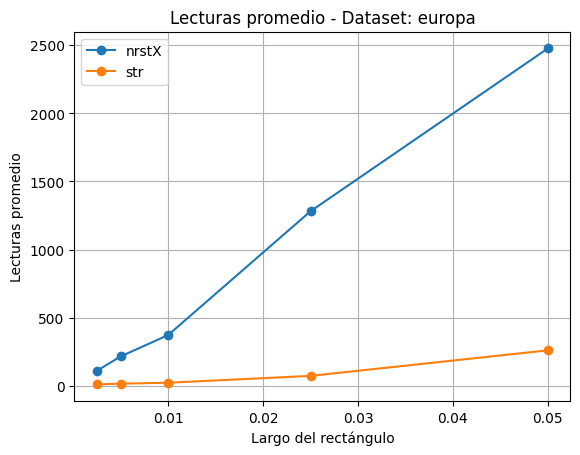

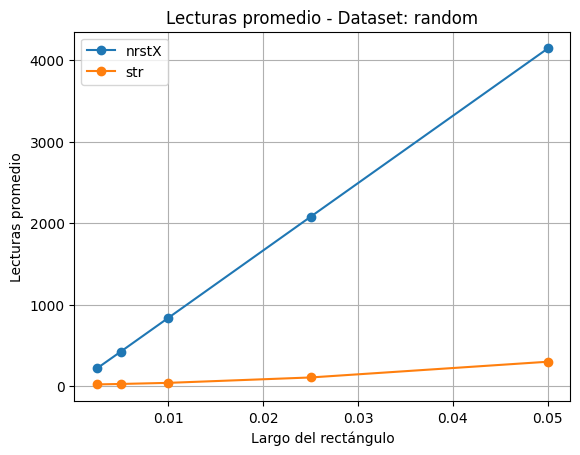

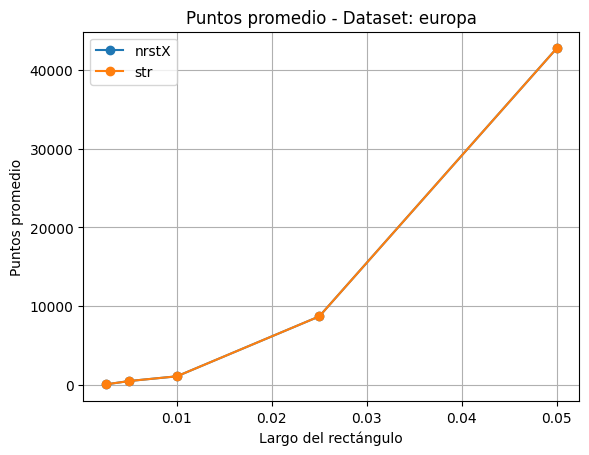

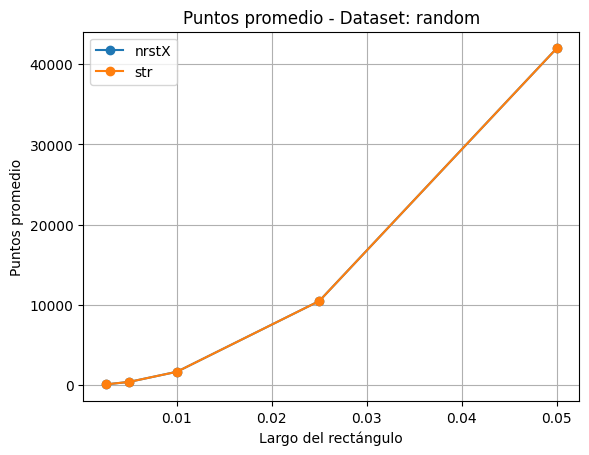

In [21]:
# Cargar datos
df = pd.read_csv("../arboles/metricas.txt")

# --- Parsear columna "arbol"
def parse_arbol(s):
    parts = s.replace(".bin", "").split("_")
    dataset = parts[1]
    modelo = parts[2] # por si modelo tiene underscores
    return dataset, modelo

df[['dataset', 'modelo']] = df['arbol'].apply(
    lambda x: pd.Series(parse_arbol(x))
)

# --- AGRUPAR DATOS (promedios)
grouped = df.groupby(['dataset', 'modelo', 'largo_rectangulo']).agg({
    'lecturas': 'mean',
    'puntos': 'mean'
}).reset_index()

# Obtener datasets únicos
datasets = grouped['dataset'].unique()

# =========================================================
# 1️⃣ GRAFICOS: LECTURAS PROMEDIO
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()

    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.plot(
            data_modelo['largo_rectangulo'],
            data_modelo['lecturas'],
            marker='o',
            label=modelo
        )

    plt.title(f"Lecturas promedio - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Lecturas promedio")
    plt.legend()
    plt.grid()

    plt.savefig(f"grafico_lecturas_{dataset}.png")
    
    plt.show()


# =========================================================
# 2️⃣ GRAFICOS: PUNTOS PROMEDIO (sin barras aún)
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()

    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.plot(
            data_modelo['largo_rectangulo'],
            data_modelo['puntos'],
            marker='o',
            label=modelo
        )

    plt.title(f"Puntos promedio - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Puntos promedio")
    plt.legend()
    plt.grid()
    
    plt.savefig(f"grafico_puntos_encontrados_{dataset}.png")

    plt.show()

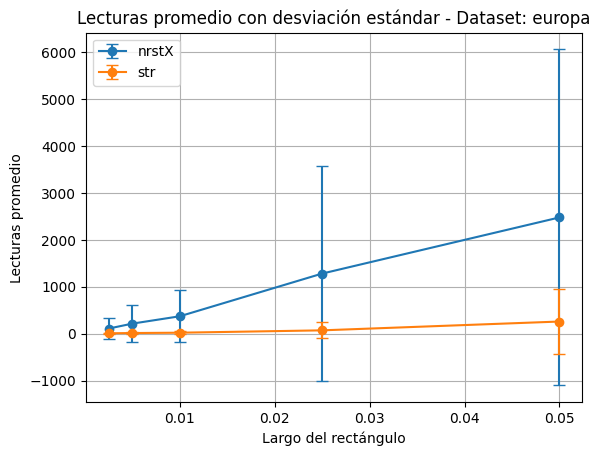

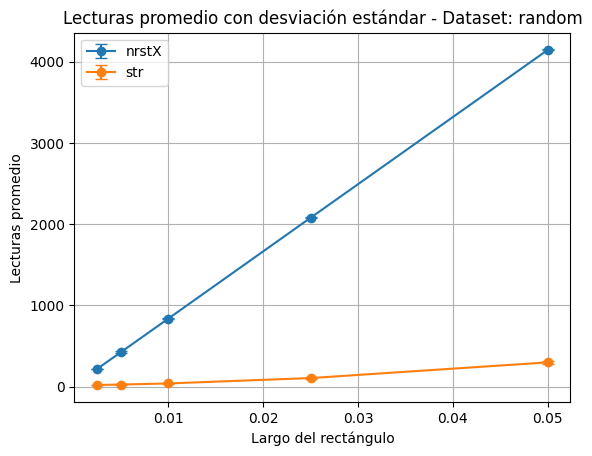

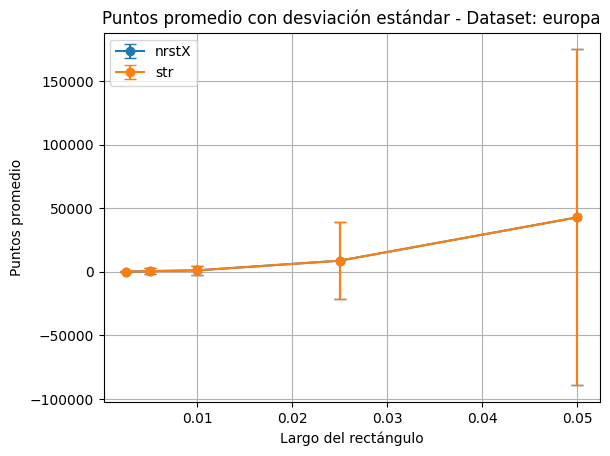

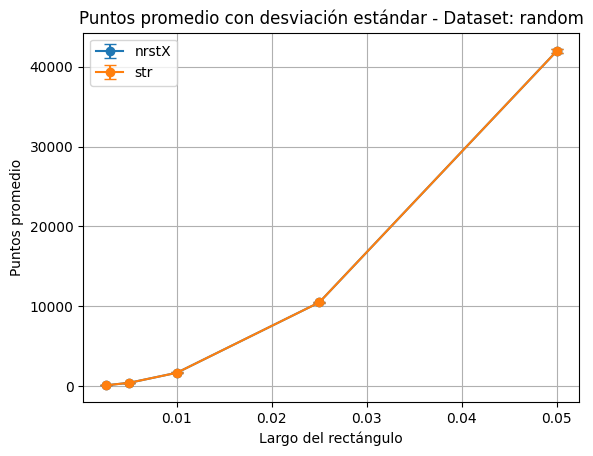

In [22]:
# =========================
# Cargar datos
# =========================
df = pd.read_csv("../arboles/metricas.txt")

# =========================
# Parsear columna "arbol"
# arbol_<dataset>_<modelo>_24.bin
# =========================
def parse_arbol(s):
    parts = s.replace(".bin", "").split("_")
    dataset = parts[1]
    modelo = "_".join(parts[2:-1])
    return dataset, modelo

df[['dataset', 'modelo']] = df['arbol'].apply(
    lambda x: pd.Series(parse_arbol(x))
)

# =========================
# Agrupar: promedio + std
# =========================
grouped = df.groupby(['dataset', 'modelo', 'largo_rectangulo']).agg({
    'lecturas': ['mean', 'std'],
    'puntos': ['mean', 'std']
}).reset_index()

# Aplanar nombres de columnas
grouped.columns = [
    'dataset', 'modelo', 'largo_rectangulo',
    'lecturas_mean', 'lecturas_std',
    'puntos_mean', 'puntos_std'
]

# =========================
# Obtener datasets
# =========================
datasets = grouped['dataset'].unique()

# =========================================================
# 1️⃣ GRAFICOS: LECTURAS + BARRAS DE ERROR
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()

    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.errorbar(
            data_modelo['largo_rectangulo'],
            data_modelo['lecturas_mean'],
            yerr=data_modelo['lecturas_std'],
            marker='o',
            capsize=4,
            label=modelo
        )

    plt.title(f"Lecturas promedio con desviación estándar - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Lecturas promedio")
    plt.legend()
    plt.grid()

    plt.savefig(f"grafico_lecturas_std_{dataset}.png")
    plt.show()


# =========================================================
# 2️⃣ GRAFICOS: PUNTOS + BARRAS DE ERROR
# =========================================================
for dataset in datasets:
    subset = grouped[grouped['dataset'] == dataset]

    plt.figure()

    for modelo in subset['modelo'].unique():
        data_modelo = subset[subset['modelo'] == modelo]
        data_modelo = data_modelo.sort_values(by='largo_rectangulo')

        plt.errorbar(
            data_modelo['largo_rectangulo'],
            data_modelo['puntos_mean'],
            yerr=data_modelo['puntos_std'],
            marker='o',
            capsize=4,
            label=modelo
        )

    plt.title(f"Puntos promedio con desviación estándar - Dataset: {dataset}")
    plt.xlabel("Largo del rectángulo")
    plt.ylabel("Puntos promedio")
    plt.legend()
    plt.grid()

    plt.savefig(f"grafico_puntos_encontrado_std_{dataset}.png")
    plt.show()